NOTE: This is the final script used for the RF model (weighting and down-sampling)

# Reformat Training Data & Retrain Model
This script aims to transform the training data that was generated from R to a python-friendly format.
Transformations include: 
- remove dots from column names
- change "percentile" to "%ile" that is used in the aggregated files
- change driver_gene column name to "Gene of Interest"

We will load the pre-imputed data such that we will find a python function to impute missing values that will be consisitant for the future. The model will be tuned and trained on this new data to compare to the previous version in 07_ml_randomForest.ipynb

The model should be the one to be used on new cases. 

NOTE: the reason why we are not training with the data from the 05_cleaning_imputation.py script is because I noticed the imputer has probably been updated, and each time I try imputed the results are different and the best results so far was data from the R (pd.read_excel(project_dir / "output" / "05_cleaning_imputation.Rmd" / "merged_df_ml2_replace.xlsx"))

In [30]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, accuracy_score, f1_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer # experimental
from sklearn.model_selection import train_test_split, GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import joblib


Set project and output directories: 

In [31]:
# Set the working directory
project_dir = Path("/Users/Jennie/Desktop/WashU/Rotation_labs/Griffith Lab/Neoantigen ML project")
os.chdir(project_dir)

# Define output directory
outdir = project_dir / "output_python" / "transform_training_data_model.ipynb"
os.makedirs(outdir, exist_ok=True)
print(f"Output directory created at: {outdir}")


Output directory created at: /Users/Jennie/Desktop/WashU/Rotation_labs/Griffith Lab/Neoantigen ML project/output_python/transform_training_data_model.ipynb


Load pre-imputed data from R

In [32]:
# load the pre-imputed data
pre_imputed_data = pd.read_excel(project_dir / "output" / "05_cleaning_imputation.Rmd" / "merged_df_ml2_replace.xlsx")
print(pre_imputed_data.head())
pre_imputed_data.shape


                              ID Evaluation  TSL  Pos  Prob.Pos  \
0     chr1-11833944-11833945-G-A     Accept    1  2.0         0   
1   chr1-159440212-159440213-G-A    Pending    6  8.0         0   
2  chr11-124038758-124038759-C-A    Pending    6  1.0         0   
3    chr12-25245349-25245350-C-T     Accept    1  5.0         0   
4    chr12-78177209-78177210-A-T     Reject    1  9.0         0   

   Num.Passing.Peptides  RNA.Expr  RNA.VAF  Allele.Expr  RNA.Depth  ...  \
0                     2    15.729    0.353        5.552      218.0  ...   
1                    10     0.010    0.000        0.000        0.0  ...   
2                     2     0.000    0.000        0.000        0.0  ...   
3                     3    21.814    0.341        7.439      569.0  ...   
4                     0     9.642    0.230        2.218      100.0  ...   

   SMM.MT.IC50.Score  SMM.WT.Percentile SMM.MT.Percentile  \
0         341.326494               46.0              15.0   
1         124.322576    

(1324, 75)

Rename columns to remove ".", change "driver_gene" to "Gene of Interest", change "percentile" to "%ile". 

In [33]:
# %% Edit column names and Evaluation values -------------------------------------------------------------------------------------------------------------
# Replace all "." with a space " "
pre_imputed_data.columns = pre_imputed_data.columns.str.replace(".", " ", regex=False)
# rename "driver_gene" to "Gene of Interest"
pre_imputed_data.rename(columns={"driver_gene": "Gene of Interest"}, inplace=True)
# Rename "percentile" to "%ile"
pre_imputed_data.rename(columns=lambda x: x.replace("percentile", "%ile"), inplace=True)

# Change "Pending" to "Reject"
#pre_imputed_data['Evaluation'] = pre_imputed_data['Evaluation'].replace('Pending', 'Reject')
# Drop "Review" from the dataset
#
print(pre_imputed_data.columns.tolist())
# Save a copy of pre_imputed_data in the output directory
pre_imputed_data.to_csv(outdir / "pre_imputed_data.csv", index=False)
print(f"Pre-imputed data saved to: {outdir / 'pre_imputed_data.csv'}")


['ID', 'Evaluation', 'TSL', 'Pos', 'Prob Pos', 'Num Passing Peptides', 'RNA Expr', 'RNA VAF', 'Allele Expr', 'RNA Depth', 'DNA VAF', 'Ref Match', 'Biotype', 'Variant Type', 'Peptide Length', 'Best MT IC50 Score', 'Corresponding WT IC50 Score', 'Corresponding Fold Change', 'Best MT Percentile', 'Corresponding WT Percentile', 'Median Fold Change', 'cysteine_count', 'IC50 MT class1', 'IC50 WT class1', 'IC50 MT class2', 'IC50 WT class2', '%ile MT class1', '%ile WT class1', '%ile MT class2', '%ile WT class2', 'MHCflurryEL Processing WT Score', 'MHCflurryEL Processing MT Score', 'MHCflurryEL Presentation WT Score', 'MHCflurryEL Presentation MT Score', 'MHCflurryEL Presentation WT Percentile', 'MHCflurryEL Presentation MT Percentile', 'MHCflurry WT IC50 Score', 'MHCflurry MT IC50 Score', 'MHCflurry WT Percentile', 'MHCflurry MT Percentile', 'MHCnuggetsI WT IC50 Score', 'MHCnuggetsI MT IC50 Score', 'MHCnuggetsI WT Percentile', 'MHCnuggetsI MT Percentile', 'NetMHC WT IC50 Score', 'NetMHC MT IC5

Encode categorical variables

In [34]:
categorical_columns = pre_imputed_data.select_dtypes(include=['category', 'object']).columns.drop(['Evaluation', 'ID', 'patient_id'])
print("Categorical columns:", categorical_columns)

# Step 2: Label encode categorical columns
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    pre_imputed_data[col] = le.fit_transform(pre_imputed_data[col])
    label_encoders[col] = le  # Store the encoder for future use


Categorical columns: Index(['Biotype', 'Variant Type', 'Prob match', 'Gene of Interest'], dtype='object')


## Impute missing values

NOTE: the chunk below was commented out since IterativeImputer is considered experimental. For reproducibility purposes, I am reading in the previously imputed data instead of imputing it again. 

Remove "Review"  
Change "Pending" to "Reject"

In [35]:
post_imputed_data = pd.read_csv(outdir / "df_imputed_python.csv")


In [36]:
# Filter out "Review" and replace "Pending" with "Reject"
post_imputed_data = post_imputed_data[post_imputed_data['Evaluation'] != 'Review']  # Remove rows with "Review"
post_imputed_data['Evaluation'] = post_imputed_data['Evaluation'].replace('Pending', 'Reject')  # Replace "Pending" with "Reject"

# Encode "Accept" as 1 and "Reject" as 0
post_imputed_data['Evaluation'] = post_imputed_data['Evaluation'].map({'Accept': 1, 'Reject': 0})

#Check the mapping
label_encoders['Evaluation'] = {'Accept': 1, 'Reject': 0}
print("Mapping for categorical variables:")
for col, le in label_encoders.items():
    print(f"Mapping for {col}:")
    if isinstance(le, LabelEncoder):
        for class_index, class_label in enumerate(le.classes_):
            print(f"  {class_label} -> {class_index}")
    elif isinstance(le, dict):
        for class_label, class_index in le.items():
            print(f"  {class_label} -> {class_index}")


Mapping for categorical variables:
Mapping for Biotype:
  IG_V_gene -> 0
  nonsense_mediated_decay -> 1
  protein_coding -> 2
Mapping for Variant Type:
  FS -> 0
  inframe_del -> 1
  inframe_ins -> 2
  missense -> 3
Mapping for Prob match:
  NO -> 0
  YES -> 1
  nan -> 2
Mapping for Gene of Interest:
  NO -> 0
  YES -> 1
Mapping for Evaluation:
  Accept -> 1
  Reject -> 0


## Split data into training and testing

In [37]:
# read the training and testing sets
train_data = pd.read_csv(outdir / "train_data_python.csv")
test_data = pd.read_csv(outdir / "test_data_python.csv")

# print the size of the training and testing sets
print(f"Training set size: {train_data.shape}")
print(f"Testing set size: {test_data.shape}")

# Separate features and target for training data
X_train = train_data.drop(columns=['Evaluation'])
y_train = train_data['Evaluation']

# Separate features and target for testing data
X_test = test_data.drop(columns=['Evaluation'])
y_test = test_data['Evaluation']

# Drop "ID" and "patient_id" columns from training and testing datasets
X_train = X_train.drop(columns=['ID', 'patient_id'])
X_test = X_test.drop(columns=['ID', 'patient_id'])

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")


Training set size: (927, 75)
Testing set size: (310, 75)
X_train shape: (927, 72), X_test shape: (310, 72)


# RF with down-sampling

## Tune random forest

## Train

In [38]:
best_mtry = joblib.load(outdir / "best_mtry_rf.pkl")
best_ntree = joblib.load(outdir / "best_ntree_rf.pkl")
# print best_mtry and best_ntree
print(f"Best max_features (mtry): {best_mtry}")
print(f"Best n_estimators (ntree): {best_ntree}")


Best max_features (mtry): 28
Best n_estimators (ntree): 101


In [39]:

# Train the final Random Forest model
rf_ds = BalancedRandomForestClassifier(
    n_estimators=best_ntree,
    max_features=best_mtry,
    oob_score=True, 
    random_state=918,
    n_jobs=-1,
    replacement=True,
    bootstrap=True  # Set bootstrap=True for OOB estimation
)
rf_ds.fit(X_train, y_train)

# Save the trained model
joblib.dump(rf_ds, outdir / "rf_downsample_model.pkl")
joblib.dump(rf_ds, project_dir / "output_python" / "model_artifacts" / "rf_downsample_model.pkl")


['/Users/Jennie/Desktop/WashU/Rotation_labs/Griffith Lab/Neoantigen ML project/output_python/model_artifacts/rf_downsample_model.pkl']

In [40]:
# read the model
rf_ds = joblib.load(outdir / "rf_downsample_model.pkl")


## OOB

OOB Error: 0.08306364617044226
OOB Confusion Matrix:
[[643  72]
 [  5 207]]
Sensitivity (Recall or True Positive Rate): 0.9764150943396226
Specificity (True Negative Rate): 0.8993006993006993


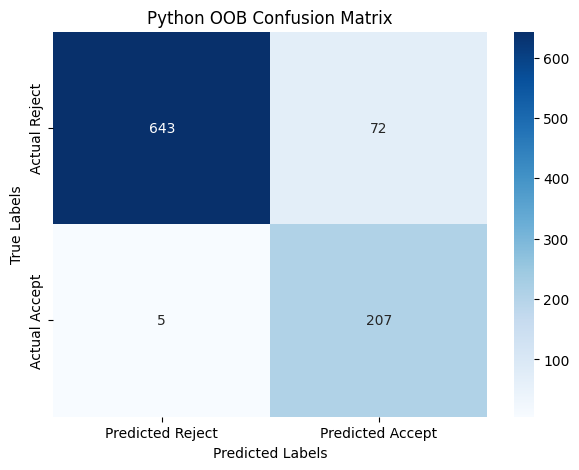

OOB ROC AUC: 0.9802909354796148


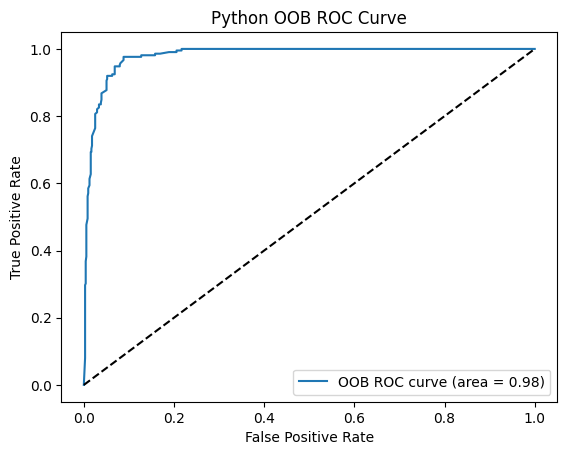

In [41]:
# Evaluate the model
oob_error = 1 - rf_ds.oob_score_
print(f"OOB Error: {oob_error}") # the proportion of misclassified samples among the OOB samples.

# extract the OOB predictions
oob_predictions = rf_ds.oob_decision_function_[:, 1] > 0.5 
# each row corresponds to a sample and each column corresponds to the class probabilities. 
# The first column ([:, 0]) gives the probability of the negative class ("Reject" in our case since it is mapped to 0).
# The second column ([:, 1]) gives the probability of the positive class ("Accept" in our case since it is mapped to 1).
# "True" for predicted as "Reject"

# Convert boolean predictions to integers
oob_predictions_int = oob_predictions.astype(int) # change True to 1 and False to 0 (0: Reject, 1: Accept)

# Calculate the confusion matrix
oob_conf_matrix = confusion_matrix(y_train, oob_predictions_int)
# The confusion matrix is a 2x2 matrix with the following structure:
# [[TN, FP],
# [FN, TP]]

print("OOB Confusion Matrix:")
print(oob_conf_matrix)

# Extract TN, FP, FN, TP from the confusion matrix
TN, FP, FN, TP = oob_conf_matrix.ravel()

# Calculate sensitivity and specificity
oob_sensitivity = TP / (TP + FN)
oob_specificity = TN / (TN + FP)

print(f"Sensitivity (Recall or True Positive Rate): {oob_sensitivity}")
print(f"Specificity (True Negative Rate): {oob_specificity}")

# Plot the confusion matrix with labels
plt.figure(figsize=(7, 5))
sns.heatmap(oob_conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Reject', 'Predicted Accept'], # column names
            yticklabels=['Actual Reject', 'Actual Accept']) # row names
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Python OOB Confusion Matrix')
plt.savefig(outdir / "oob_conf_matrix.png")
plt.show()

# Calculate OOB ROC AUC
rf_ds_oob_roc_auc = roc_auc_score(y_train, rf_ds.oob_decision_function_[:, 1])
print(f"OOB ROC AUC: {rf_ds_oob_roc_auc}")

# Plot OOB ROC curve
fpr, tpr, _ = roc_curve(y_train, rf_ds.oob_decision_function_[:, 1])
plt.plot(fpr, tpr, label=f'OOB ROC curve (area = {rf_ds_oob_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Python OOB ROC Curve')
plt.legend(loc='best')
plt.savefig(outdir / "oob_roc_curve.png")
plt.show()


## Test set evaluation

Test Set Confusion Matrix:
[[208  17]
 [ 13  72]]
Test Set Accuracy: 0.9032258064516129
Sensitivity (Recall or True Positive Rate): 0.8470588235294118
Specificity (True Negative Rate): 0.9244444444444444
Test Set ROC AUC: 0.9552679738562092
Test Set F1 Score: 0.8275862068965517


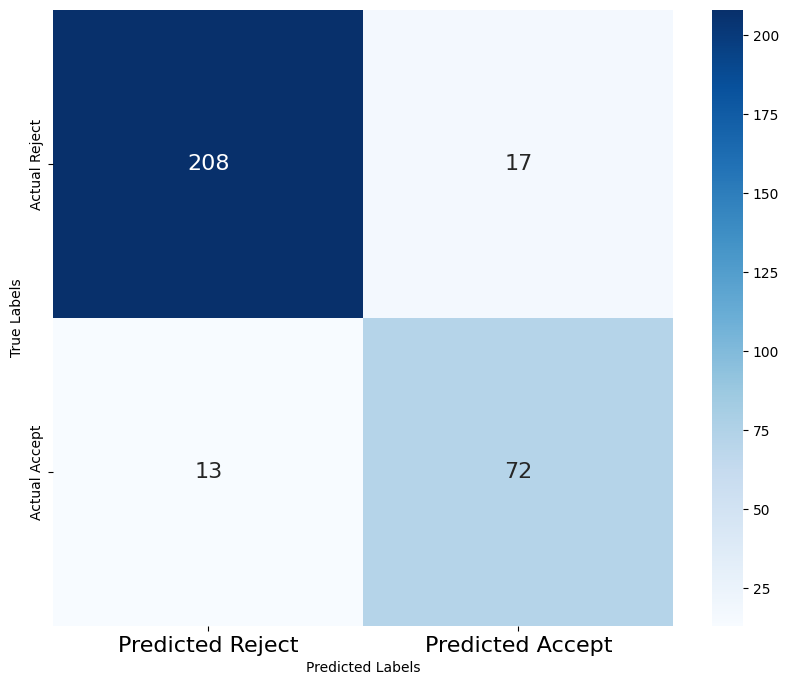

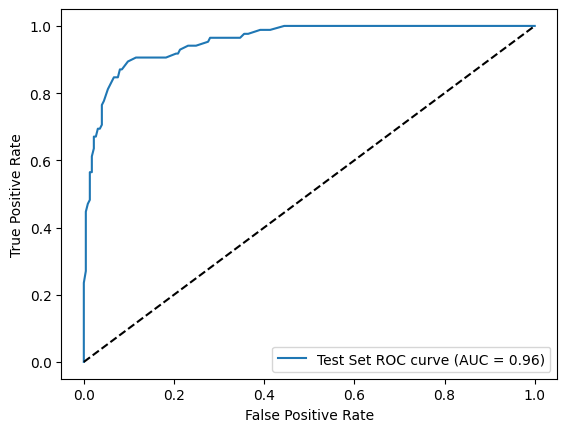

In [42]:
# Predict on test set
rf_ds_pred = rf_ds.predict(X_test)

rf_ds_conf_matrix = confusion_matrix(y_test, rf_ds_pred)
print("Test Set Confusion Matrix:")
print(rf_ds_conf_matrix)

rf_ds_pred_accuracy = accuracy_score(y_test, rf_ds_pred)
print(f"Test Set Accuracy: {rf_ds_pred_accuracy}")

# Extract TN, FP, FN, TP from the confusion matrix and convert to standard Python integers
TN, FP, FN, TP = [int(x) for x in rf_ds_conf_matrix.ravel()]

# Calculate sensitivity and specificity
rf_ds_sensitivity = TP / (TP + FN)
rf_ds_specificity = TN / (TN + FP)

print(f"Sensitivity (Recall or True Positive Rate): {rf_ds_sensitivity}")
print(f"Specificity (True Negative Rate): {rf_ds_specificity}")


rf_ds_pred_prob = rf_ds.predict_proba(X_test)[:, 1]
rf_ds_roc_auc = roc_auc_score(y_test, rf_ds_pred_prob)
print(f"Test Set ROC AUC: {rf_ds_roc_auc}")

# Calculate F1 score
rf_ds_f1 = f1_score(y_test, rf_ds_pred)
print(f"Test Set F1 Score: {rf_ds_f1}")

plt.figure(figsize=(10, 8))
sns.heatmap(rf_ds_conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Reject', 'Predicted Accept'], # column names
            yticklabels=['Actual Reject', 'Actual Accept'], # row names
            annot_kws={'size': 16})  # Make numbers larger
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(fontsize=16)
#plt.title('Random Forest with Down-samping Test set Confusion Matrix')
plt.savefig(outdir / "rf_ds_test_conf_matrix.png")
plt.show()

#plt.figure(figsize=(10, 8))
fpr, tpr, _ = roc_curve(y_test, rf_ds_pred_prob)
plt.plot(fpr, tpr, label=f'Test Set ROC curve (AUC = {rf_ds_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
#plt.title('Test Set ROC Curve')
plt.legend(loc='best')
plt.savefig(outdir / "rf_ds_test_set_roc_curve.png")
plt.show()


Test Set AUC-PR (down-sampling): 0.8989098134803009


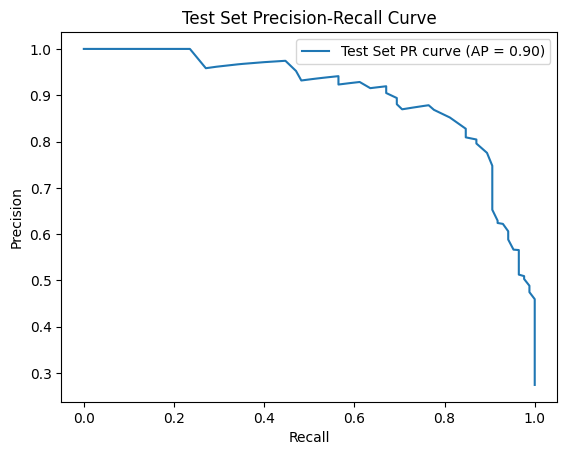

In [43]:
from sklearn.metrics import precision_recall_curve, average_precision_score
# For test set predictions
test_precision, test_recall, test_thresholds = precision_recall_curve(y_test, rf_ds.predict_proba(X_test)[:, 1])
rf_ds_auc_pr = average_precision_score(y_test, rf_ds.predict_proba(X_test)[:, 1])

print(f"Test Set AUC-PR (down-sampling): {rf_ds_auc_pr}")
#plt.figure(figsize=(8, 6))
plt.plot(test_recall, test_precision, label=f'Test Set PR curve (AP = {rf_ds_auc_pr:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Test Set Precision-Recall Curve')
plt.legend()
plt.savefig(outdir / "rf_ds_test_set_pr_curve.png")
#plt.grid(True)
plt.show()


## Variable of importance
In scikit-learn's RandomForestClassifier, the feature importance is computed as:

**Mean Decrease in Impurity (MDI)**: The total reduction in impurity (weighted by the number of samples passing through the split) for each feature, averaged across all trees in the forest.
The feature importance values are normalized so that they sum to 1.

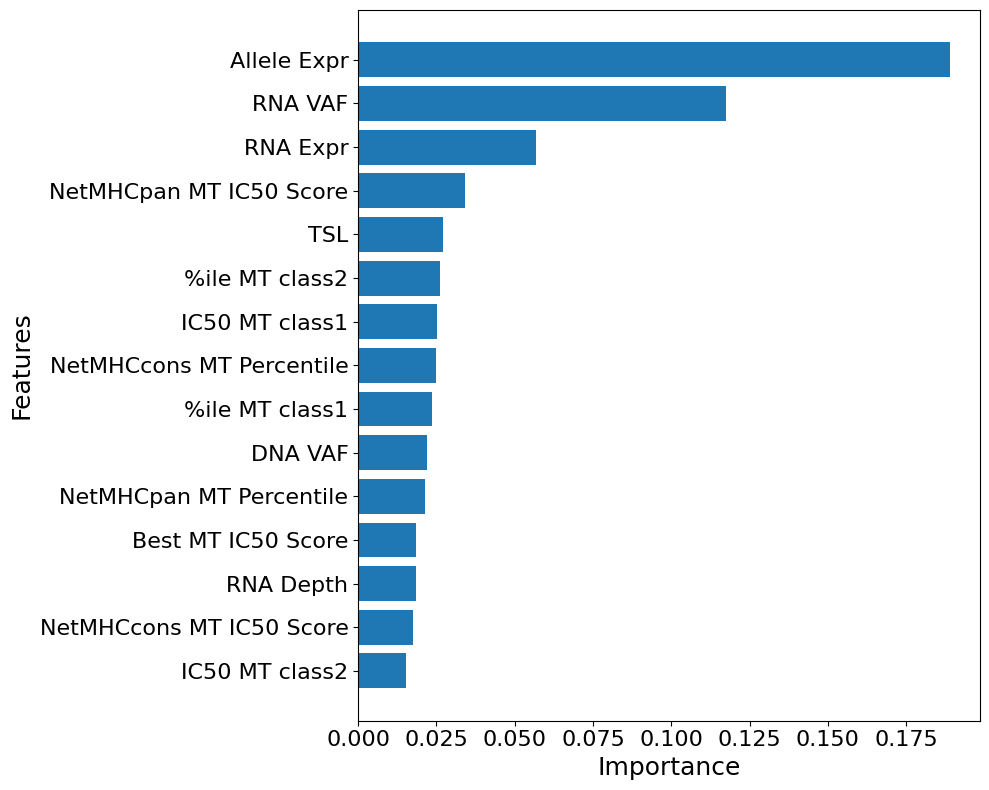

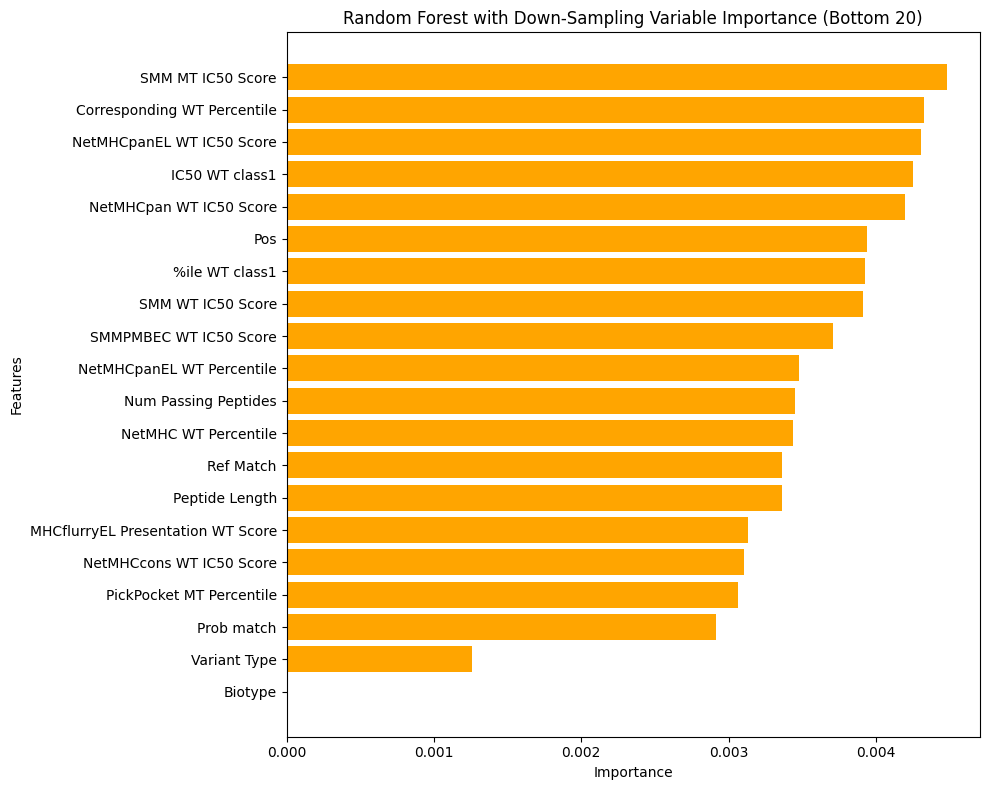

In [44]:
# Variable importance
importances = rf_ds.feature_importances_
indices = np.argsort(importances)[::-1]
features = X_train.columns

# Export a CSV file with feature importance, feature name, and importance score. Order by most important at top.
feature_importance_df = pd.DataFrame({
    "Feature": features[indices],
    "Importance": importances[indices]
})
feature_importance_df.to_csv(outdir / "rf_ds_feature_importance.csv", index=False)


# 
plt.figure(figsize=(10, 8))
#plt.title("Random Forest with Down-Sampling Variable Importance (Top 15)", fontsize=20)
plt.barh(range(15), importances[indices[:15]], align="center")
plt.yticks(range(15), features[indices[:15]], fontsize=16)  # Increase y-tick label size
plt.xticks(fontsize=16)  # Increase x-tick label size
plt.gca().invert_yaxis()  # Invert y-axis to have the most important feature at the top
plt.xlabel('Importance', fontsize=18)
plt.ylabel('Features', fontsize=18)
plt.tight_layout()
plt.savefig(outdir / "rf_ds_variable_importance_top_15.png")
plt.show()

# Plot the bottom 20 variable importance with flipped axes
plt.figure(figsize=(10, 8))
plt.title("Random Forest with Down-Sampling Variable Importance (Bottom 20)")
plt.barh(range(20), importances[indices[-20:]], align="center", color="orange")  # Set bar color to orange
plt.yticks(range(20), features[indices[-20:]])
plt.gca().invert_yaxis()  # Invert y-axis to have the least important feature at the top
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig(outdir / "rf_ds_variable_importance_bottom_20.png")
plt.show()


# RF with class weighting


## Train

## OOB

In [45]:
# read the model
rf_classweight = joblib.load(outdir / "rf_classweight_model.pkl")


OOB Error: 0.1326860841423948
OOB Confusion Matrix:
[[677  38]
 [ 85 127]]
Sensitivity (Recall or True Positive Rate): 0.5990566037735849
Specificity (True Negative Rate): 0.9468531468531468
OOB ROC AUC: 0.9107665918986674


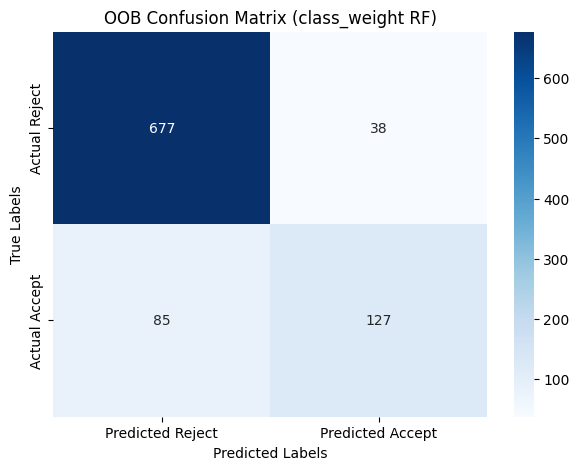

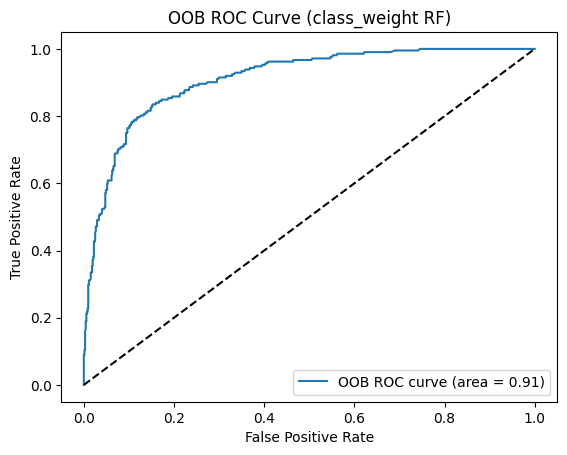

In [46]:
# OOB error
oob_error = 1 - rf_classweight.oob_score_
print(f"OOB Error: {oob_error}")

# OOB predictions and confusion matrix
oob_predictions = rf_classweight.oob_decision_function_[:, 1] > 0.5
oob_predictions_int = oob_predictions.astype(int)
oob_conf_matrix = confusion_matrix(y_train, oob_predictions_int)
print("OOB Confusion Matrix:")
print(oob_conf_matrix)

TN, FP, FN, TP = oob_conf_matrix.ravel()
oob_sensitivity = TP / (TP + FN)
oob_specificity = TN / (TN + FP)
print(f"Sensitivity (Recall or True Positive Rate): {oob_sensitivity}")
print(f"Specificity (True Negative Rate): {oob_specificity}")

# OOB ROC AUC
rf_classweight_oob_roc_auc = roc_auc_score(y_train, rf_classweight.oob_decision_function_[:, 1])
print(f"OOB ROC AUC: {rf_classweight_oob_roc_auc}")

# OOB Confusion Matrix Plot
plt.figure(figsize=(7, 5))
sns.heatmap(oob_conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Reject', 'Predicted Accept'],
            yticklabels=['Actual Reject', 'Actual Accept'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('OOB Confusion Matrix (class_weight RF)')
plt.show()

# OOB ROC Curve
fpr, tpr, _ = roc_curve(y_train, rf_classweight.oob_decision_function_[:, 1])
plt.plot(fpr, tpr, label=f'OOB ROC curve (area = {rf_classweight_oob_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('OOB ROC Curve (class_weight RF)')
plt.legend(loc='best')
plt.show()


## Test set evaluation

Test Set Confusion Matrix:
[[221   4]
 [ 33  52]]
Test Set Accuracy: 0.8806451612903226
Sensitivity (Recall or True Positive Rate): 0.611764705882353
Specificity (True Negative Rate): 0.9822222222222222
Test Set ROC AUC: 0.9608104575163399
Test Set F1 Score: 0.7375886524822695


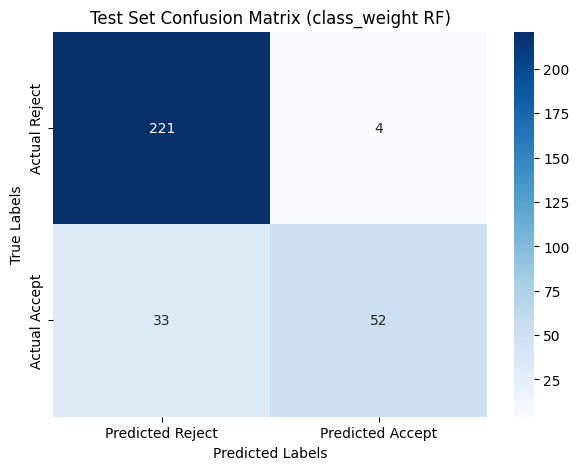

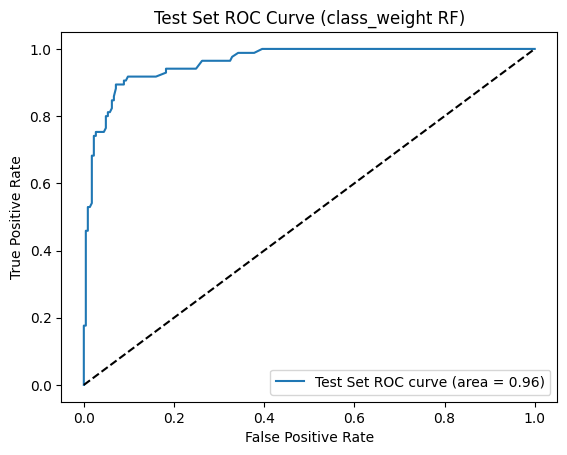

In [47]:
# Predict on test set
rf_classweight_pred = rf_classweight.predict(X_test)
rf_classweight_conf_matrix = confusion_matrix(y_test, rf_classweight_pred)
print("Test Set Confusion Matrix:")
print(rf_classweight_conf_matrix)

rf_classweight_pred_accuracy = accuracy_score(y_test, rf_classweight_pred)
print(f"Test Set Accuracy: {rf_classweight_pred_accuracy}")

TN, FP, FN, TP = [int(x) for x in rf_classweight_conf_matrix.ravel()]
rf_classweight_sensitivity = TP / (TP + FN)
rf_classweight_specificity = TN / (TN + FP)
print(f"Sensitivity (Recall or True Positive Rate): {rf_classweight_sensitivity}")
print(f"Specificity (True Negative Rate): {rf_classweight_specificity}")

rf_classweight_pred_prob = rf_classweight.predict_proba(X_test)[:, 1]
rf_classweight_roc_auc = roc_auc_score(y_test, rf_classweight_pred_prob)
print(f"Test Set ROC AUC: {rf_classweight_roc_auc}")

# Calculate F1 score
rf_classweight_f1 = f1_score(y_test, rf_classweight_pred)
print(f"Test Set F1 Score: {rf_classweight_f1}")

plt.figure(figsize=(7, 5))
sns.heatmap(rf_classweight_conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Reject', 'Predicted Accept'],
            yticklabels=['Actual Reject', 'Actual Accept'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Test Set Confusion Matrix (class_weight RF)')
plt.show()

fpr, tpr, _ = roc_curve(y_test, rf_classweight_pred_prob)
plt.plot(fpr, tpr, label=f'Test Set ROC curve (area = {rf_classweight_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Test Set ROC Curve (class_weight RF)')
plt.legend(loc='best')
plt.show()


Test Set AUC-PR (class_weight): 0.9075446548216756


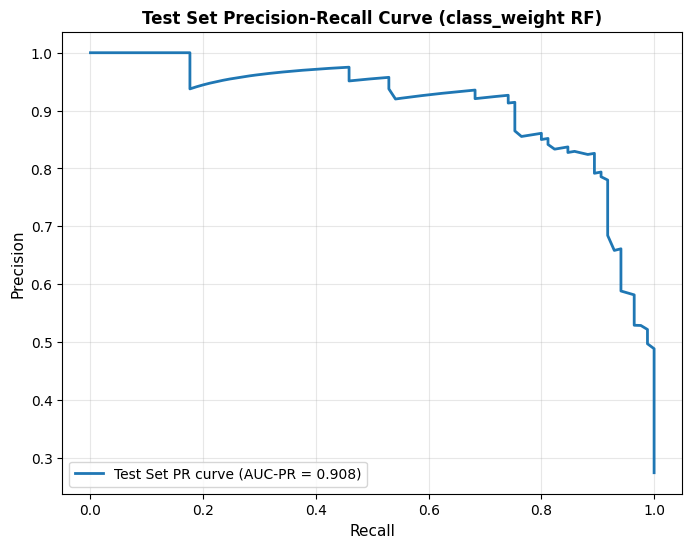

In [48]:
# PR curve for rf_classweight
from sklearn.metrics import precision_recall_curve, average_precision_score

# Calculate precision, recall, and AUC-PR for test set
# Reuse rf_classweight_pred_prob that was already calculated
precision_classweight, recall_classweight, thresholds_classweight = precision_recall_curve(y_test, rf_classweight_pred_prob)
rf_classweight_auc_pr = average_precision_score(y_test, rf_classweight_pred_prob)

print(f"Test Set AUC-PR (class_weight): {rf_classweight_auc_pr}")

# Plot PR curve
plt.figure(figsize=(8, 6))
plt.plot(recall_classweight, precision_classweight, label=f'Test Set PR curve (AUC-PR = {rf_classweight_auc_pr:.3f})', linewidth=2)
plt.xlabel('Recall', fontsize=11)
plt.ylabel('Precision', fontsize=11)
plt.title('Test Set Precision-Recall Curve (class_weight RF)', fontsize=12, fontweight='bold')
plt.legend(loc='lower left', fontsize=10)
plt.grid(alpha=0.3)
plt.savefig(outdir / "rf_classweight_test_set_pr_curve.png", dpi=300, bbox_inches='tight')
plt.show()


# RF without down-sampling or weighing for comparison

In [49]:
rf_default = RandomForestClassifier(
    random_state=918,
    oob_score=True,  # want OOB score
    n_jobs=-1
)

rf_default.fit(X_train, y_train)


# OOB error
oob_error = 1 - rf_default.oob_score_
print(f"OOB Error: {oob_error}")

# OOB predictions and confusion matrix
oob_predictions = rf_default.oob_decision_function_[:, 1] > 0.5
oob_predictions_int = oob_predictions.astype(int)
oob_conf_matrix = confusion_matrix(y_train, oob_predictions_int)
print("OOB Confusion Matrix:")
print(oob_conf_matrix)
# OOB ROC AUC
rf_default_oob_roc_auc = roc_auc_score(y_train, rf_default.oob_decision_function_[:, 1])
print(f"OOB ROC AUC: {rf_default_oob_roc_auc}")


# Predict on test set
rf_default_pred = rf_default.predict(X_test)
rf_default_conf_matrix = confusion_matrix(y_test, rf_default_pred)
print("Test Set Confusion Matrix:")
print(rf_default_conf_matrix)

rf_default_pred_accuracy = accuracy_score(y_test, rf_default_pred)
print(f"Test Set Accuracy: {rf_default_pred_accuracy}")

TN, FP, FN, TP = [int(x) for x in rf_default_conf_matrix.ravel()]
rf_default_sensitivity = TP / (TP + FN)
rf_default_specificity = TN / (TN + FP)
print(f"Sensitivity (Recall or True Positive Rate): {rf_default_sensitivity}")
print(f"Specificity (True Negative Rate): {rf_default_specificity}")

rf_default_pred_prob = rf_default.predict_proba(X_test)[:, 1]
rf_default_roc_auc = roc_auc_score(y_test, rf_default_pred_prob)
print(f"Test Set ROC AUC: {rf_default_roc_auc}")

# Calculate F1 score
rf_default_f1 = f1_score(y_test, rf_default_pred)
print(f"Test Set F1 Score: {rf_default_f1}")


OOB Error: 0.13807982740021574
OOB Confusion Matrix:
[[682  33]
 [ 95 117]]
OOB ROC AUC: 0.8900349650349649
Test Set Confusion Matrix:
[[221   4]
 [ 39  46]]
Test Set Accuracy: 0.8612903225806452
Sensitivity (Recall or True Positive Rate): 0.5411764705882353
Specificity (True Negative Rate): 0.9822222222222222
Test Set ROC AUC: 0.915607843137255
Test Set F1 Score: 0.6814814814814815


Test Set AUC-PR (default): 0.8312455919302733


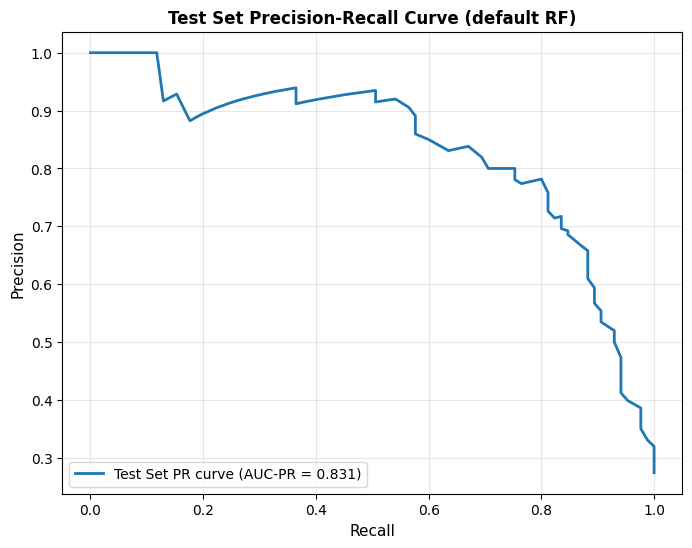

In [50]:
# PR curve for rf_default
from sklearn.metrics import precision_recall_curve, average_precision_score

# Calculate precision, recall, and AUC-PR for test set
# Reuse rf_default_pred_prob that was already calculated
precision_default, recall_default, thresholds_default = precision_recall_curve(y_test, rf_default_pred_prob)
rf_default_auc_pr = average_precision_score(y_test, rf_default_pred_prob)

print(f"Test Set AUC-PR (default): {rf_default_auc_pr}")

# Plot PR curve
plt.figure(figsize=(8, 6))
plt.plot(recall_default, precision_default, label=f'Test Set PR curve (AUC-PR = {rf_default_auc_pr:.3f})', linewidth=2)
plt.xlabel('Recall', fontsize=11)
plt.ylabel('Precision', fontsize=11)
plt.title('Test Set Precision-Recall Curve (default RF)', fontsize=12, fontweight='bold')
plt.legend(loc='lower left', fontsize=10)
plt.grid(alpha=0.3)
plt.savefig(outdir / "rf_default_test_set_pr_curve.png", dpi=300, bbox_inches='tight')
plt.show()


# Summary

In [54]:
import pandas as pd

# Fill these with your actual results from the notebook, report 3 significant figures
def sig3(x):
    try:
        return float(f"{x:.3g}")
    except Exception:
        return x

results = {
    "Model": [
        "Random Forest", 
        "Random Forest with weighting", 
        "Random Forest with down-sampling"
    ],
    "OOB AUC": [
        sig3(rf_default_oob_roc_auc),      # from rf_default
        sig3(rf_classweight_oob_roc_auc),  # from rf_classweight
        sig3(rf_ds_oob_roc_auc)      # from BalancedRandomForestClassifier
    ],
    "Accuracy": [
        sig3(rf_default_pred_accuracy),
        sig3(rf_classweight_pred_accuracy),
        sig3(rf_ds_pred_accuracy)
    ],
    "Sensitivity": [
        sig3(rf_default_sensitivity),
        sig3(rf_classweight_sensitivity),
        sig3(rf_ds_sensitivity)
    ],
    "Specificity": [
        sig3(rf_default_specificity),
        sig3(rf_classweight_specificity),
        sig3(rf_ds_specificity)
    ],
    "F1": [
        sig3(rf_default_f1),
        sig3(rf_classweight_f1),
        sig3(rf_ds_f1)
    ],
    "AUROC": [
        sig3(rf_default_roc_auc),
        sig3(rf_classweight_roc_auc),
        sig3(rf_ds_roc_auc)
    ],
    "AUPR": [
        sig3(rf_default_auc_pr),
        sig3(rf_classweight_auc_pr),
        sig3(rf_ds_auc_pr)
    ]
}

summary_df = pd.DataFrame(results)
print(summary_df)


                              Model  OOB AUC  Accuracy  Sensitivity  \
0                     Random Forest    0.890     0.861        0.541   
1      Random Forest with weighting    0.911     0.881        0.612   
2  Random Forest with down-sampling    0.980     0.903        0.847   

   Specificity     F1  AUROC   AUPR  
0        0.982  0.681  0.916  0.831  
1        0.982  0.738  0.961  0.908  
2        0.924  0.828  0.955  0.899  
